In [293]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib




In [294]:
df = pd.read_csv("C:/Users/jaine/OneDrive/Desktop/COLLEGE PROJECT/data/supply_chain_demand.csv")

In [295]:
print("DATASET SHAPE:", df.shape)

DATASET SHAPE: (5000, 27)


In [296]:
print("FIRST 5 ROWS:")
df.head()

FIRST 5 ROWS:


,Order_ID,Order_Date,Product_ID,Product_Category,Product_Name,Region,City,Supplier_ID,Supplier_Lead_Time_Days,Warehouse_ID,...,Promotion,Holiday,Season,Weather,Competitor_Price,Stockout_Days,Delivery_Delay_Days,Transportation_Cost,Customer_Return_Rate,Demand_Quantity
0,ORD100000,2024-04-02,P-BEA-004,Beauty,Talcum Powder,North,Delhi,SUP-034,4.0,WH-NO-05,...,No,No,Summer,Sunny,1033.61,0.0,21.0,218.83,0.129,22
1,ORD100001,2023-02-19,P-CLO-006,Clothing,Cotton Saree,West,Surat,SUP-019,13.0,WH-WE-04,...,Yes,No,Spring,Sunny,618.38,0.0,2.0,476.26,0.021,29
2,ORD100002,2024-03-14,P-BEA-013,Beauty,Lipstick Set,West,Pune,SUP-028,11.0,WH-WE-02,...,No,No,Summer,Sunny,749.79,0.0,1.0,379.62,0.023,20
3,ORD100003,2021-10-26,P-FUR-002,Furniture,Study Table,North,Jaipur,SUP-039,2.0,WH-NO-05,...,No,Yes,Autumn,Rainy,7279.16,0.0,NaN,440.40,0.048,9
4,ORD100004,2022-01-27,P-ELE-002,Electronics,Smartphone Charger,North,Chandigarh,SUP-002,4.0,WH-NO-05,...,No,No,Winter,Sunny,5218.89,0.0,1.0,239.47,0.072,10


In [297]:
print("DATA TYPES:")
df.dtypes

DATA TYPES:


Order_ID                    object
Order_Date                  object
Product_ID                  object
Product_Category            object
Product_Name                object
Region                      object
City                        object
Supplier_ID                 object
Supplier_Lead_Time_Days    float64
Warehouse_ID                object
Current_Inventory          float64
Previous_Day_Sales         float64
Previous_7_Days_Sales      float64
Previous_30_Days_Sales     float64
Average_Daily_Sales        float64
Unit_Price                 float64
Discount_Percentage        float64
Promotion                   object
Holiday                     object
Season                      object
Weather                     object
Competitor_Price           float64
Stockout_Days              float64
Delivery_Delay_Days        float64
Transportation_Cost        float64
Customer_Return_Rate       float64
Demand_Quantity              int64
dtype: object

In [298]:
print("MISSING VALUES PER COLUMN:")
df.isnull().sum()

MISSING VALUES PER COLUMN:


Order_ID                     0
Order_Date                   0
Product_ID                   0
Product_Category             0
Product_Name                 0
Region                       0
City                       156
Supplier_ID                  0
Supplier_Lead_Time_Days    153
Warehouse_ID                 0
Current_Inventory          187
Previous_Day_Sales         155
Previous_7_Days_Sales      145
Previous_30_Days_Sales     158
Average_Daily_Sales        100
Unit_Price                 101
Discount_Percentage        142
Promotion                  152
Holiday                    125
Season                     128
Weather                    248
Competitor_Price           107
Stockout_Days              182
Delivery_Delay_Days        173
Transportation_Cost        186
Customer_Return_Rate       169
Demand_Quantity              0
dtype: int64

In [299]:
print("DUPLICATE ROWS:")
df.duplicated().sum()

DUPLICATE ROWS:


np.int64(0)

In [300]:
df = df.drop_duplicates()

In [301]:
print("BASIC STATISTICS:")
df.describe()

BASIC STATISTICS:


,Supplier_Lead_Time_Days,Current_Inventory,Previous_Day_Sales,Previous_7_Days_Sales,Previous_30_Days_Sales,Average_Daily_Sales,Unit_Price,Discount_Percentage,Competitor_Price,Stockout_Days,Delivery_Delay_Days,Transportation_Cost,Customer_Return_Rate,Demand_Quantity
count,4847.000000,4813.000000,4845.000000,4855.000000,4842.000000,4900.000000,4899.000000,4858.000000,4893.000000,4818.000000,4827.000000,4814.000000,4831.000000,5000.000000
mean,8.783784,316.145439,21.810733,147.759629,634.772408,21.236957,3662.629324,12.522520,3622.897936,0.106061,1.240729,382.501545,0.089472,24.111600
std,4.489760,372.949800,20.417471,102.760857,435.750851,14.320757,4725.991403,8.273734,4606.632071,0.426154,2.054594,136.017370,0.060248,18.222084
min,1.000000,7.000000,0.000000,14.000000,63.000000,2.270000,50.880000,0.100000,42.900000,0.000000,0.000000,50.000000,0.001000,0.000000
25%,6.000000,113.000000,9.000000,68.000000,290.250000,9.777500,487.160000,6.000000,483.270000,0.000000,0.000000,301.070000,0.044000,11.000000
50%,8.000000,216.000000,16.000000,120.000000,522.000000,17.545000,1417.780000,11.000000,1404.250000,0.000000,1.000000,366.425000,0.077000,19.000000
75%,11.000000,409.000000,29.000000,201.000000,869.000000,29.045000,4864.685000,17.800000,4892.590000,0.000000,2.000000,444.245000,0.121000,32.000000
max,37.000000,8898.000000,379.000000,832.000000,3457.000000,107.620000,50145.940000,45.200000,24001.150000,8.000000,27.000000,2375.310000,0.404000,172.000000


In [302]:
print("New Shape After Duplicate")
df.shape

New Shape After Duplicate


(5000, 27)

In [303]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df["Order_Year"] = df["Order_Date"].dt.year
df["Order_Month"] = df["Order_Date"].dt.month
df["Order_Day"] = df["Order_Date"].dt.day
df["Order_DayOfWeek"] = df["Order_Date"].dt.dayofweek

In [304]:
df

,Order_ID,Order_Date,Product_ID,Product_Category,Product_Name,Region,City,Supplier_ID,Supplier_Lead_Time_Days,Warehouse_ID,...,Competitor_Price,Stockout_Days,Delivery_Delay_Days,Transportation_Cost,Customer_Return_Rate,Demand_Quantity,Order_Year,Order_Month,Order_Day,Order_DayOfWeek
0,ORD100000,2024-04-02,P-BEA-004,Beauty,Talcum Powder,North,Delhi,SUP-034,4.0,WH-NO-05,...,1033.61,0.0,21.0,218.83,0.129,22,2024,4,2,1
1,ORD100001,2023-02-19,P-CLO-006,Clothing,Cotton Saree,West,Surat,SUP-019,13.0,WH-WE-04,...,618.38,0.0,2.0,476.26,0.021,29,2023,2,19,6
2,ORD100002,2024-03-14,P-BEA-013,Beauty,Lipstick Set,West,Pune,SUP-028,11.0,WH-WE-02,...,749.79,0.0,1.0,379.62,0.023,20,2024,3,14,3
3,ORD100003,2021-10-26,P-FUR-002,Furniture,Study Table,North,Jaipur,SUP-039,2.0,WH-NO-05,...,7279.16,0.0,NaN,440.40,0.048,9,2021,10,26,1
4,ORD100004,2022-01-27,P-ELE-002,Electronics,Smartphone Charger,North,Chandigarh,SUP-002,4.0,WH-NO-05,...,5218.89,0.0,1.0,239.47,0.072,10,2022,1,27,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,ORD104995,2023-03-22,P-GRO-012,Grocery,Basmati Rice 5kg,South,Chennai,SUP-034,6.0,WH-SO-04,...,545.69,0.0,0.0,262.17,0.019,64,2023,3,22,2
4996,ORD104996,2024-12-16,P-ELE-004,Electronics,Home Router,South,Kochi,SUP-010,6.0,WH-SO-05,...,6682.17,0.0,0.0,245.73,0.203,7,2024,12,16,0
4997,ORD104997,2021-08-23,P-CLO-002,Clothing,Denim Jeans,North,Lucknow,SUP-027,9.0,WH-NO-04,...,1585.44,0.0,0.0,291.45,0.017,29,2021,8,23,0
4998,ORD104998,2022-03-29,P-GRO-001,Grocery,Sugar 1kg,South,NaN,SUP-002,2.0,WH-SO-04,...,463.40,0.0,0.0,360.04,0.020,40,2022,3,29,1


In [305]:
selected_features = [
    "Average_Daily_Sales",
    "Previous_30_Days_Sales",
    "Previous_7_Days_Sales",
    "Current_Inventory",
    "Previous_Day_Sales",
    "Discount_Percentage",
    "Promotion",
    "Customer_Return_Rate",
    "Transportation_Cost",
    "Supplier_Lead_Time_Days",
    "Competitor_Price",
    "Unit_Price"
]

X = df[selected_features]
y = df["Demand_Quantity"]

In [306]:
numerical_columns = X.select_dtypes(include=np.number).columns.tolist()
categorical_columns = X.select_dtypes(exclude=np.number).columns.tolist()

In [307]:

print("Numerical columns:", numerical_columns)
print("Categorical columns:", categorical_columns)

Numerical columns: ['Average_Daily_Sales', 'Previous_30_Days_Sales', 'Previous_7_Days_Sales', 'Current_Inventory', 'Previous_Day_Sales', 'Discount_Percentage', 'Customer_Return_Rate', 'Transportation_Cost', 'Supplier_Lead_Time_Days', 'Competitor_Price', 'Unit_Price']
Categorical columns: ['Promotion']


In [308]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [309]:
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

In [310]:
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])


In [311]:
preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_pipeline, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns),
])

In [312]:
model = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_split=15,
    min_samples_leaf=5,
    max_features=0.7,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

In [313]:
print("\nTraining the model...")
pipeline.fit(X_train, y_train)
print("Training complete.")



Training the model...
Training complete.


In [314]:
y_pred = pipeline.predict(X_test)

In [315]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [316]:

print("MODEL EVALUATION")
print("MAE =Mean Absolute Error):",mae)
print("RMSE (Root Mean Squared Error):",rmse)
print("R2 Score:",r2)

MODEL EVALUATION
MAE =Mean Absolute Error): 4.186698649881957
RMSE (Root Mean Squared Error): 6.651338032771122
R2 Score: 0.8618990988530819


In [317]:
y_train_pred = pipeline.predict(X_train)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_pred)

print("Train R2:", train_r2)
print("Test R2 :", test_r2)

Train R2: 0.9221374781666264
Test R2 : 0.8618990988530819


In [318]:
results = pd.DataFrame({
    "Actual_Demand": y_test.values[:10],
    "Predicted_Demand": np.round(y_pred[:10], 1),
})

In [319]:

print("SAMPLE PREDICTIONS (Actual vs Predicted):")
print(results.to_string(index=False))



SAMPLE PREDICTIONS (Actual vs Predicted):
 Actual_Demand  Predicted_Demand
            10              12.6
            24              24.8
            22              23.8
             4               7.2
            28              31.5
            11              16.8
             8               8.8
            51              41.7
            21              18.5
            14              13.7


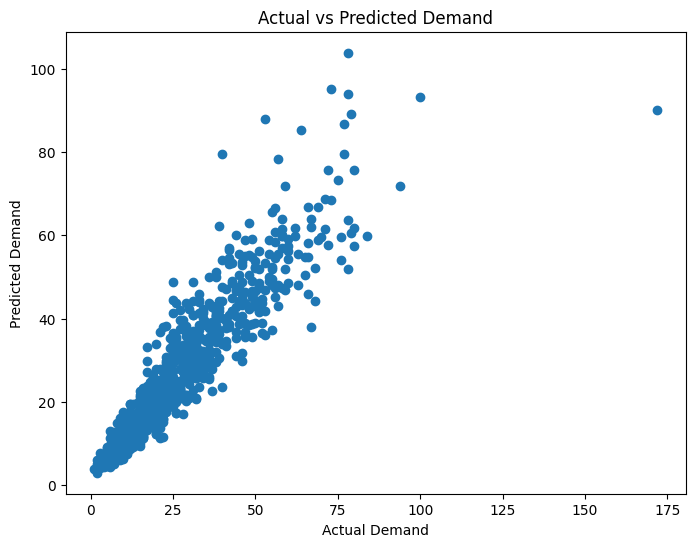

In [320]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand")

plt.show()

In [321]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

importance = pd.Series(
    pipeline.named_steps["model"].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(importance.head(20))

num__Average_Daily_Sales        0.614103
num__Previous_30_Days_Sales     0.203913
num__Previous_7_Days_Sales      0.100591
num__Current_Inventory          0.024243
num__Previous_Day_Sales         0.022982
cat__Promotion_Yes              0.007252
cat__Promotion_No               0.007096
num__Discount_Percentage        0.006426
num__Customer_Return_Rate       0.003243
num__Transportation_Cost        0.003065
num__Supplier_Lead_Time_Days    0.002640
num__Competitor_Price           0.002450
num__Unit_Price                 0.001994
dtype: float64


In [322]:
joblib.dump(pipeline, "../model/supply_chain_model.pkl")

['../model/supply_chain_model.pkl']